In [1]:
# Adapted from https://github.com/elstonlab/PhagocytosisRosetteModel/blob/main/WPGAP_FP_Check_EA_Results.ipynb by J. Cody Herron
import numpy as np
from scipy.integrate import odeint
import pickle
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import math

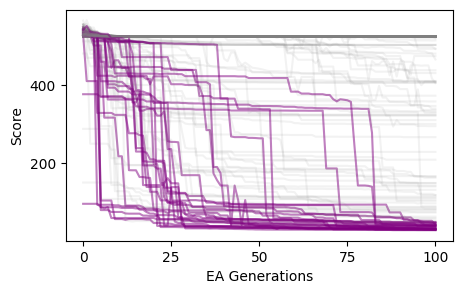

In [2]:
folder = os.getcwd()
file_loc = folder

threshold_good_score = 50
path, dirs, files = os.walk(file_loc).__next__()
len_files = 501

runs_df = pd.DataFrame(index = range(len_files), columns=['Score','a_act', 'd_act', 'K_n', 'n', 'a_x', 'd_x', 'm',
                                                          'K_S', 'K_a', 'k1', 'k2', 'k4', 'k3', 'XbsT', 'sT'])

best_scores = []
best_inds = []
plt.figure(figsize=(5,3))
for i in range(len_files):
    logbook = pickle.load( open( folder + '/' + str(i) + ".pickled", "rb" ) )
    runs_df.iloc[i] = np.insert(logbook[1][-1],0,logbook[0][-1])
        
    best_scores.append(logbook[0][-1])
    best_inds.append(logbook[1][-1])
  
    run = np.array(logbook[0])
    score = logbook[0][-1]
    if score < threshold_good_score:
        plt.plot(run,color='purple',alpha=.5)  
    else:
        plt.plot(run,color='gray',alpha=0.1)

plt.xlabel('EA Generations')
plt.ylabel('Score')
plt.rcParams.update({'font.size': 16})

best_scores = np.array(best_scores)
plt.savefig(folder+'/Scores.png',bbox_inches='tight',dpi=300)

In [3]:
good_df = runs_df[runs_df['Score'] < threshold_good_score].sort_values('Score')
good_df.to_csv('Parameters_for_transient_signal.csv', index=False)

In [4]:
good_df

,Score,a_act,d_act,K_n,n,a_x,d_x,m,K_S,K_a,k1,k2,k4,k3,XbsT,sT
211,28.498062,0.054081,0.00846,1.000085,9.895966,6.047764,0.009015,3.183048,3.814884,7.731708,0.001632,1.78466,5.508214,0.091089,100.007017,50.571273
456,29.056713,20.477829,0.022458,1.019481,9.98013,5.540321,0.027067,3.351467,3.101157,458.837532,0.005532,3.106239,13.120685,0.17445,100.043494,53.384925
469,29.304587,7.591732,0.005636,1.006365,8.496002,1.644635,0.004896,2.400529,1.374065,7963.559712,0.006719,6.378881,0.484661,0.001961,100.08097,81.98397
500,29.62919,13.948804,0.27011,1.015185,9.993566,6.518548,0.0283,2.721878,1.8527,63.716558,0.014094,9.89748,34.782876,0.282666,100.100807,55.228435
13,30.249261,9.624345,0.044188,1.002277,9.623167,2.826672,0.027375,3.291178,4.250322,21.868357,0.002303,0.841871,22.279164,0.455442,100.00579,50.545306
427,30.372373,91.56154,0.336462,1.000043,9.998543,8.347418,0.030417,4.274971,3.781028,24.102777,0.01649,9.882651,39.445516,0.561689,100.026228,51.554374
42,31.152741,3.795644,1.339515,1.002962,9.897928,9.748123,0.015161,1.556708,1.003922,1.009832,0.004511,9.805739,0.281577,0.005132,100.001515,50.028398
76,31.20916,12.730091,0.011102,1.341692,9.843406,3.258705,0.027535,3.019986,4.046388,834.05744,0.022868,7.853375,16.996783,0.426521,100.180485,50.19238
455,32.145003,85.020383,0.034883,1.088539,8.981316,1.341725,0.027016,2.776358,3.424156,225.546148,0.018374,9.087876,6.93962,0.277641,100.049169,51.85647
303,32.265136,85.96665,0.09019,1.003788,9.910999,4.953999,0.01932,4.598575,2.679908,417.359168,0.021945,8.830622,1.066588,0.003102,100.133665,76.412191


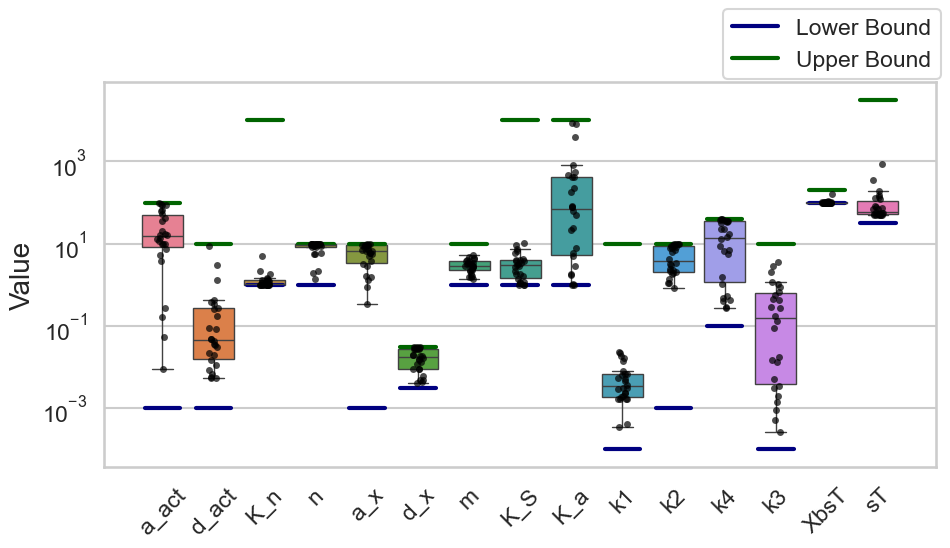

In [5]:
a_act_min = -3 #activator synthesis rate from single X chromosome
a_act_max =  2

d_act_min = -3 #degradation rate of free activator
d_act_max = 1

K_n_min = 0 #concentration of bound SPEN at which activator synthesis rate is half max.
K_n_max = 4

n_min = 0 #Hill coefficient for SPEN supressing activator synthesis rate.
n_max = 1

a_x_min = -3 #xist synthesis rate from single X chromosome
a_x_max = 1

d_x_min = -2.5 #degradation rate of Xist
d_x_max = -1.5

m_min = 0  #Hill coefficient for bound SPEN reducing dissociation rate Xist
m_max = 1

K_S_min = 0 #Half max for SPEN inhibiting Xist dissociation
K_S_max = 4

K_a_min = 0 # concentration of activator at which Xist transcription is half max.
K_a_max = 4

k1_min = -4 #rate constant for Xist binding to DNA
k1_max = 1
    
k2_min = -3 #maximum dissociation rate for Xist
k2_max = 1

k4_min = -1 #dissoication rate for bound SPEN
k4_max = 1.6

k5_min = -4 #association rate for SPEN
k5_max = 1

sT_min = 1.5 #Total SPEN concentration
sT_max = 4.5

XbsT_min = 2
XbsT_max = 2.3

# Set a clean style and context for the plot
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))
curr_df = good_df.drop(columns=['Score'])

# Use a pastel color palette for the boxplot
num_boxes = curr_df.shape[1]
unique_colors = sns.color_palette("husl", num_boxes)
sns.boxplot(data=curr_df, showfliers=False, palette=unique_colors)

# Use a softer gray for the stripplot
sns.stripplot(data=curr_df, color='k', alpha=0.7)

plt.xticks(rotation=45)
plt.ylabel('Value', fontsize=20)
plt.xlabel('')
plt.yscale('log')

# Calculate boundaries (example provided with np.power)
lower_bounds = np.power(10, [a_act_min, d_act_min, K_n_min, n_min, a_x_min, d_x_min, 
                               m_min, K_S_min, K_a_min, k1_min, k2_min, k4_min, 
                               k5_min, XbsT_min, sT_min])
upper_bounds = np.power(10, [a_act_max, d_act_max, K_n_max, n_max, a_x_max, d_x_max, 
                               m_max, K_S_max, K_a_max, k1_max, k2_max, k4_max, 
                               k5_max, XbsT_max, sT_max])

# Plot the boundaries with a more subtle style
for i, (low, high) in enumerate(zip(lower_bounds, upper_bounds)):
    plt.plot([i-0.35, i+0.35], [low, low], color='navy', linestyle='-', linewidth=3,
             label='Lower Bound' if i == 0 else "")
    plt.plot([i-0.35, i+0.35], [high, high], color='darkgreen', linestyle='-', linewidth=3,
             label='Upper Bound' if i == 0 else "")

plt.legend(loc='upper left', bbox_to_anchor=(0.73, 1.22))
plt.tight_layout()

plt.savefig(folder+'/EAParams.png', bbox_inches='tight', dpi=300)
plt.savefig(folder+'/EAParams.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [6]:
def DE1(y,t,arr_parameters_IP):
    act, x1f, x1b, s1b = y
    a_act, d_act, K_n, n, a_x, d_x, m, K_S, K_a, k1, k2, k4, k5, XbsT, sT = arr_parameters_IP
    N_S = round(sT/XbsT)
    dy = [
        a_act/(1 +(s1b/K_n)**n) - d_act*act,
        a_x*act/(K_a + act) - d_x*x1f - k1*(XbsT - x1b)*x1f + k2*x1b/(1+(s1b/K_S)**m),
        k1*(XbsT - x1b)*x1f - k2*x1b/(1+(s1b/K_S)**m),
        k5*(sT - s1b)*(N_S*x1b - s1b)  - k4*s1b
        ]
    return dy

In [7]:
def DE2(y,t,arr_parameters_IP):
    act, x1f, x1b, s1b, x2f, x2b, s2b = y
    a_act, d_act, K_n, n, a_x, d_x, m, K_S, K_a, k1, k2, k4, k5, XbsT, sT = arr_parameters_IP
    N_S = round(sT/XbsT)
    dy = [
        a_act/(1 +(s1b/K_n)**n) + a_act/(1 +(s2b/K_n)**n) - d_act*act,
        a_x*act/(K_a + act) - d_x*x1f - k1*(XbsT - x1b)*x1f + k2*x1b/(1+(s1b/K_S)**m),
        k1*(XbsT - x1b)*x1f - k2*x1b/(1+(s1b/K_S)**m),
        k5*(sT - s1b - s2b)*(N_S*x1b - s1b)  - k4*s1b,
        a_x*act/(K_a + act) - d_x*x2f - k1*(XbsT - x2b)*x2f + k2*x2b/(1+(s2b/K_S)**m),
        k1*(XbsT - x2b)*x2f - k2*x2b/(1+(s2b/K_S)**m),
        k5*(sT - s1b - s2b)*(N_S*x2b - s2b)  - k4*s2b,
        ]
    return dy

In [8]:
def DE3(y,t,arr_parameters_IP):
    act, x1f, x1b, s1b, x2f, x2b, s2b, x3f, x3b, s3b = y
    a_act, d_act, K_n, n, a_x, d_x, m, K_S, K_a, k1, k2, k4, k5, XbsT, sT = arr_parameters_IP
    N_S = round(sT/XbsT)
    dy = [
        a_act/(1 +(s1b/K_n)**n) + a_act/(1 +(s2b/K_n)**n) + a_act/(1 +(s3b/K_n)**n) - d_act*act,
        a_x*act/(K_a + act) - d_x*x1f - k1*(XbsT - x1b)*x1f + k2*x1b/(1+(s1b/K_S)**m),
        k1*(XbsT - x1b)*x1f - k2*x1b/(1+(s1b/K_S)**m),
        k5*(sT - s1b - s2b - s3b)*(N_S*x1b - s1b)  - k4*s1b,
        a_x*act/(K_a + act) - d_x*x2f - k1*(XbsT - x2b)*x2f + k2*x2b/(1+(s2b/K_S)**m),
        k1*(XbsT - x2b)*x2f - k2*x2b/(1+(s2b/K_S)**m),
        k5*(sT - s1b - s2b - s3b)*(N_S*x2b - s2b)  - k4*s2b,
        a_x*act/(K_a + act) - d_x*x3f - k1*(XbsT - x3b)*x3f + k2*x3b/(1+(s3b/K_S)**m),
        k1*(XbsT - x3b)*x3f - k2*x3b/(1+(s3b/K_S)**m),
        k5*(sT - s1b - s2b - s3b)*(N_S*x3b - s3b)  - k4*s3b
        ]
    return dy

In [9]:
param = good_df.iloc[0][1:]
sT = param[-1]
XbsT = param[-2]
param

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_90262/214326390.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sT = param[-1]
/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_90262/214326390.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  XbsT = param[-2]


a_act      0.054081
d_act       0.00846
K_n        1.000085
n          9.895966
a_x        6.047764
d_x        0.009015
m          3.183048
K_S        3.814884
K_a        7.731708
k1         0.001632
k2          1.78466
k4         5.508214
k3         0.091089
XbsT     100.007017
sT        50.571273
Name: 211, dtype: object

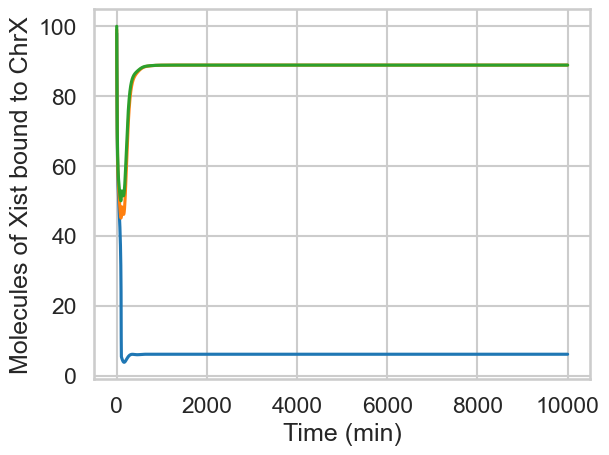

In [10]:
final_time = 10000
time_step = 0.01
n_time_point = round(final_time/time_step)

IC = [0,  #act;
          0,  #x1f;
          XbsT-2,  #x1b;
          0,  #s1b;
          0,  #x2f;
          XbsT-1, #x2b
          0, #s2b
          0, #x3f
          XbsT, #x3b
          0 #s3b
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE3, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
act = y[:,0]
x1b = y[:,2]
x2b = y[:,5]
x3b = y[:,8]
s1b = y[:,3]
s2b = y[:,6]
s3b = y[:,9]
plt.figure()
plt.plot(time, x1b)
plt.plot(time, x2b)
plt.plot(time, x3b)
plt.xlabel('Time (min)')
plt.ylabel('Molecules of Xist bound to ChrX')
#plt.ylim(0,250)
plt.show()

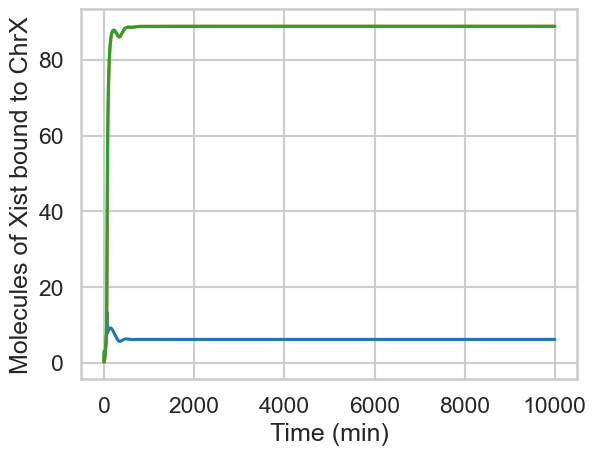

In [11]:
IC = [0,  #act;
          0,  #x1f;
          1,  #x1b;
          0,  #s1b;
          0,  #x2f;
          2, #x2b
          0, #s2b
          0, #x3f
          3, #x3b
          0 #s3b
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE3, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
act = y[:,0]
x1b = y[:,2]
x2b = y[:,5]
x3b = y[:,8]
s1b = y[:,3]
s2b = y[:,6]
s3b = y[:,9]
plt.figure()
plt.plot(time, x1b)
plt.plot(time, x2b)
plt.plot(time, x3b)
plt.xlabel('Time (min)')
plt.ylabel('Molecules of Xist bound to ChrX')
#plt.ylim(0,250)
plt.show()

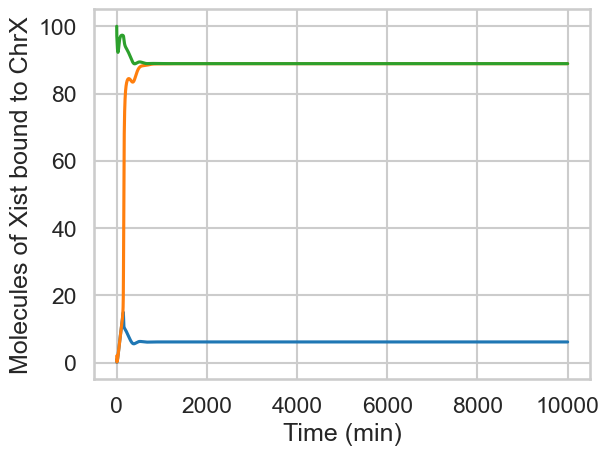

In [12]:
IC = [0,  #act;
          0,  #x1f;
          1,  #x1b;
          0,  #s1b;
          0,  #x2f;
          2, #x2b
          0, #s2b
          0, #x3f
          XbsT, #x3b
          0 #s3b
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE3, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
act = y[:,0]
x1b = y[:,2]
x2b = y[:,5]
x3b = y[:,8]
s1b = y[:,3]
s2b = y[:,6]
s3b = y[:,9]
plt.figure()
plt.plot(time, x1b)
plt.plot(time, x2b)
plt.plot(time, x3b)
plt.xlabel('Time (min)')
plt.ylabel('Molecules of Xist bound to ChrX')
#plt.ylim(0,250)
plt.show()

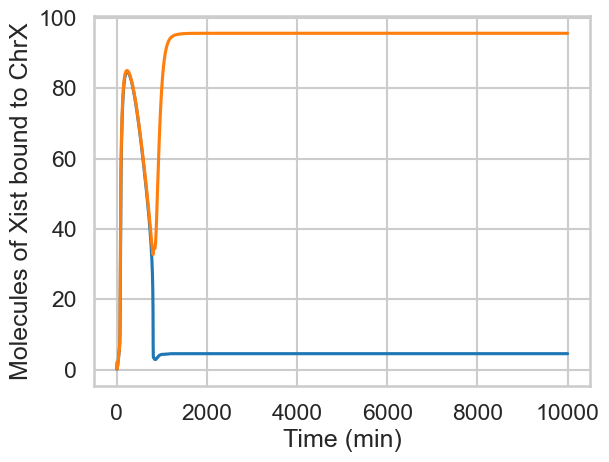

In [13]:
IC = [0,  #act;
          0,  #x1f;
          1,  #x1b;
          0,  #s1b;
          0,  #x2f;
          2, #x2b
          0, #s2b
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE2, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
x1b = y[:,2]
x2b = y[:,5]
plt.figure()
plt.plot(time, x1b)
plt.plot(time, x2b)
plt.xlabel('Time (min)')
plt.ylabel('Molecules of Xist bound to ChrX')
#plt.ylim(0,250)
plt.show()

np.float64(0.6302447603485313)

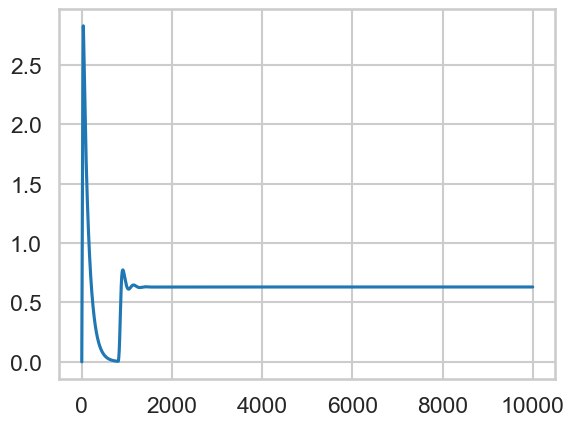

In [14]:
free_act = y[:,0]
free_spen = sT - y[:,3] - y[:,6]
plt.figure()
plt.plot(time,free_act)
free_act[-1]

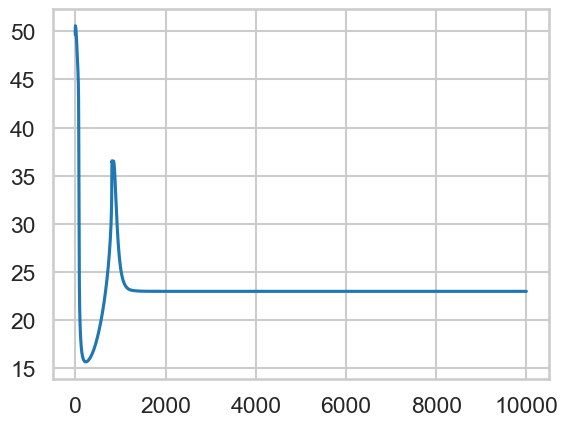

In [15]:
plt.figure
plt.plot(time,free_spen)

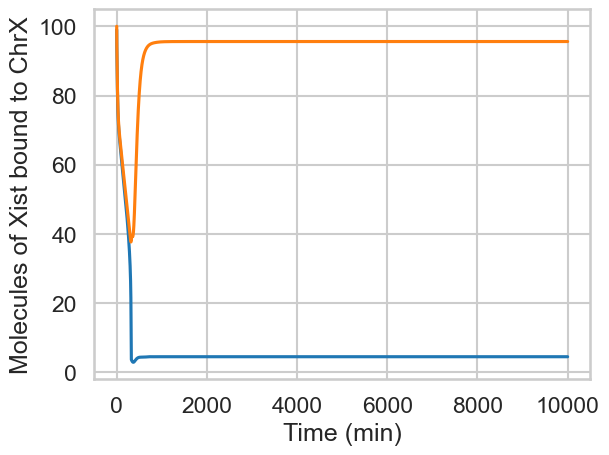

In [16]:
IC = [0,  #act;
          0,  #x1f;
          XbsT-1,  #x1b;
          0,  #s1b;
          0,  #x2f;
          XbsT, #x2b
          0, #s2b
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE2, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
x1b = y[:,2]
x2b = y[:,5]
plt.figure()
plt.plot(time, x1b)
plt.plot(time, x2b)
plt.xlabel('Time (min)')
plt.ylabel('Molecules of Xist bound to ChrX')
#plt.ylim(0,250)
plt.show()

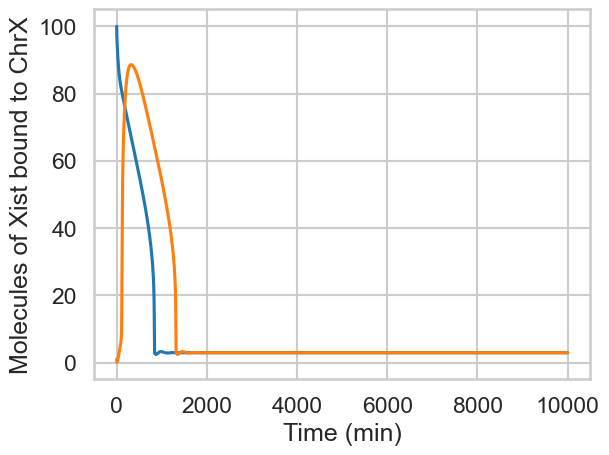

In [17]:
IC = [0,  #act;
          0,  #x1f;
          XbsT,  #x1b;
          0,  #s1b;
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE1, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
act = y[:,0]
x1b = y[:,2]
plt.figure()
plt.plot(time, x1b)
plt.xlabel('Time (min)')
plt.ylabel('Molecules of Xist bound to ChrX')

IC = [0,  #act;
          0,  #x1f;
          1,  #x1b;
          0,  #s1b;
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE1, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
act = y[:,0]
x1b = y[:,2]
plt.plot(time, x1b)

#plt.ylim(0,250)
plt.show()

In [18]:
free_act = y[:,0]
free_act[-1]

np.float64(0.3875308229890337)

In [19]:
# seed 12, 21, 26, 32, 34

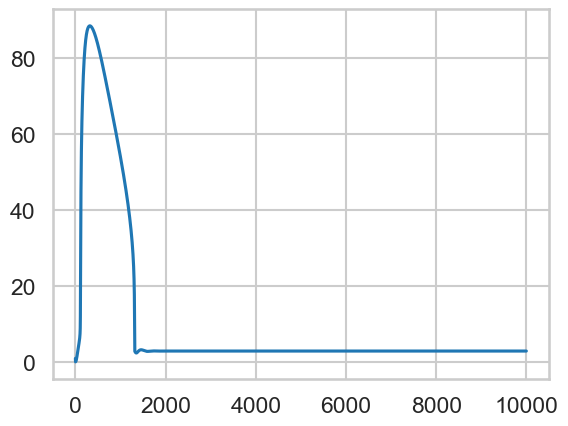

In [20]:
IC = [0,  #act;
          0,  #x1f;
          1,  #x1b;
          0,  #s1b;
         ]
time = np.linspace(0,final_time,n_time_point)
y = odeint(DE1, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
act = y[:,0]
x1b = y[:,2]
plt.plot(time, x1b)

#plt.ylim(0,250)
plt.show()

In [21]:
def all_equal(arr):
    arr = np.asarray(arr)
    return arr.size == 0 or np.all(arr == arr.flat[0])

In [22]:
final_time = 10000
n_time_point = final_time*10
idx = []
for i in range(0, len(good_df)):
    param = good_df.iloc[i][1:]
    max_x1b = param[-2]
    ic_x1b = range(0,math.ceil(max_x1b))
    x1b_ss = np.zeros([1,len(ic_x1b)])
    for j in range(len(x1b_ss)):
        IC = [0,  #act;
              0,  #x1f;
              ic_x1b[j],  #x1b;
              0,  #s1b;
             ]
        time = np.linspace(0,final_time,n_time_point)
        y = odeint(DE1, IC, time, args=(param,), rtol = 0.5e-8, atol=1e-12)
        x1b_ss[j] = y[-1,2]
    if not all_equal(x1b_ss):
        idx.append(i)

        

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_90262/93626223.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_x1b = param[-2]


In [23]:
idx

[]

In [24]:
len(good_df)

26